# I-JEPA Core Operations in JAX

This notebook builds on `data_patch.ipynb` to explain the **core operations** of I-JEPA:

1. **Patches as indices, not 2D grids** - Why masks are just lists of integers
2. **`apply_masks`** - The key gather operation that selects patches
3. **2D Positional Embeddings** - How geometry is encoded
4. **Context + Mask Tokens** - How the predictor sees its input
5. **Full I-JEPA Forward** - Putting it all together

The key insight: **shapes don't matter once you have indices**. A "Swiss cheese" context block is just a set of patch indices.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import einops
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import ListedColormap

# For nice visualizations
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams['figure.dpi'] = 100

## 1. The Patch Grid: From 2D Image to 1D Sequence

An image becomes a sequence of patch tokens. Each patch has an **index** in the flattened sequence.

In [2]:
# Create a simple 8x8 "image" with 2x2 patches -> 4x4 = 16 patches
IMG_SIZE = 8
PATCH_SIZE = 2
N_PATCHES_PER_DIM = IMG_SIZE // PATCH_SIZE  # 4
N_PATCHES = N_PATCHES_PER_DIM ** 2  # 16

print(f"Image: {IMG_SIZE}x{IMG_SIZE} pixels")
print(f"Patch size: {PATCH_SIZE}x{PATCH_SIZE}")
print(f"Grid: {N_PATCHES_PER_DIM}x{N_PATCHES_PER_DIM} = {N_PATCHES} patches")

Image: 8x8 pixels
Patch size: 2x2
Grid: 4x4 = 16 patches


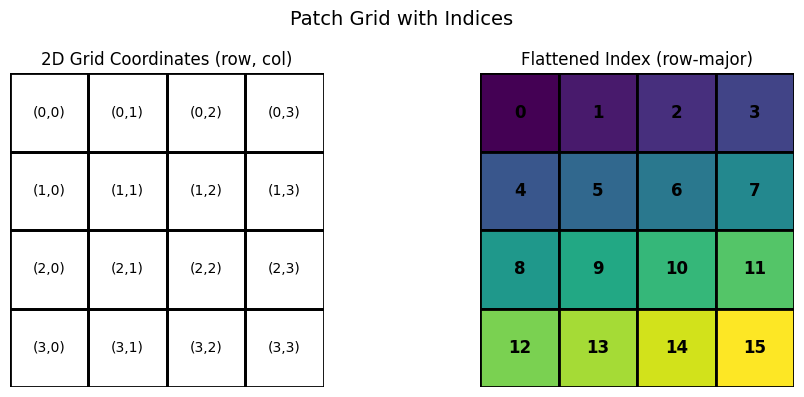

In [3]:
def visualize_patch_indices(n_patches_per_dim, title="Patch Grid with Indices"):
    """Show how 2D grid maps to 1D indices (row-major / raster order)"""
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    # Left: 2D grid with (row, col) coordinates
    ax = axes[0]
    for i in range(n_patches_per_dim):
        for j in range(n_patches_per_dim):
            ax.add_patch(Rectangle((j, n_patches_per_dim-1-i), 1, 1, 
                                   fill=False, edgecolor='black', linewidth=2))
            ax.text(j + 0.5, n_patches_per_dim - 0.5 - i, f'({i},{j})', 
                   ha='center', va='center', fontsize=10)
    ax.set_xlim(0, n_patches_per_dim)
    ax.set_ylim(0, n_patches_per_dim)
    ax.set_aspect('equal')
    ax.set_title('2D Grid Coordinates (row, col)')
    ax.axis('off')
    
    # Right: Same grid with flattened indices
    ax = axes[1]
    colors = plt.cm.viridis(np.linspace(0, 1, n_patches_per_dim**2))
    for i in range(n_patches_per_dim):
        for j in range(n_patches_per_dim):
            idx = i * n_patches_per_dim + j  # Row-major ordering
            ax.add_patch(Rectangle((j, n_patches_per_dim-1-i), 1, 1, 
                                   facecolor=colors[idx], edgecolor='black', linewidth=2))
            ax.text(j + 0.5, n_patches_per_dim - 0.5 - i, f'{idx}', 
                   ha='center', va='center', fontsize=12, fontweight='bold')
    ax.set_xlim(0, n_patches_per_dim)
    ax.set_ylim(0, n_patches_per_dim)
    ax.set_aspect('equal')
    ax.set_title('Flattened Index (row-major)')
    ax.axis('off')
    
    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    return fig

visualize_patch_indices(N_PATCHES_PER_DIM)
plt.show()

In [4]:
# Converting between 2D coordinates and 1D indices
def coords_to_idx(row, col, width):
    """(row, col) -> flat index"""
    return row * width + col

def idx_to_coords(idx, width):
    """flat index -> (row, col)"""
    return idx // width, idx % width

# Example: patch at (1, 2) in a 4x4 grid
row, col = 1, 2
idx = coords_to_idx(row, col, N_PATCHES_PER_DIM)
print(f"Patch at (row={row}, col={col}) has index {idx}")
print(f"Index {idx} maps back to {idx_to_coords(idx, N_PATCHES_PER_DIM)}")

Patch at (row=1, col=2) has index 6
Index 6 maps back to (1, 2)


## 2. Masks Are Just Index Lists

In I-JEPA, a "block" is defined by a set of patch indices. The actual shape (rectangle, Swiss cheese, etc.) doesn't matter to the model - it just sees a list of tokens.

**Key insight**: `mask = [5, 6, 9, 10]` means "use patches 5, 6, 9, 10" regardless of their 2D arrangement.

In [5]:
def sample_rectangular_block(key, h, w, grid_h, grid_w):
    """Sample a rectangular block and return its indices.
    
    Args:
        key: JAX random key
        h, w: height and width of block (in patches)
        grid_h, grid_w: size of patch grid
    
    Returns:
        indices: 1D array of patch indices in the block
    """
    k1, k2 = jax.random.split(key)
    top = jax.random.randint(k1, (), 0, grid_h - h + 1)
    left = jax.random.randint(k2, (), 0, grid_w - w + 1)
    
    # Generate all (row, col) pairs in the block
    rows = jnp.arange(top, top + h)
    cols = jnp.arange(left, left + w)
    
    # Meshgrid and flatten to get indices
    rr, cc = jnp.meshgrid(rows, cols, indexing='ij')
    indices = rr.flatten() * grid_w + cc.flatten()
    
    return indices, (int(top), int(left), h, w)

# Sample a 2x2 target block
key = jax.random.PRNGKey(42)
target_indices, (top, left, bh, bw) = sample_rectangular_block(key, 2, 2, N_PATCHES_PER_DIM, N_PATCHES_PER_DIM)

print(f"Target block at (top={top}, left={left}), size {bh}x{bw}")
print(f"Target indices: {target_indices}")
print(f"These correspond to positions: {[idx_to_coords(int(i), N_PATCHES_PER_DIM) for i in target_indices]}")

Target block at (top=1, left=2), size 2x2
Target indices: [ 6  7 10 11]
These correspond to positions: [(1, 2), (1, 3), (2, 2), (2, 3)]


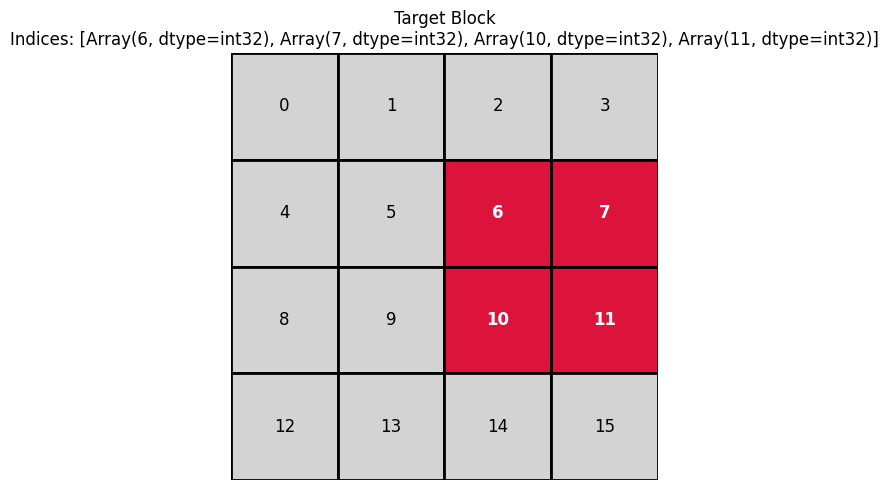

In [6]:
def visualize_indices_on_grid(indices, n_patches_per_dim, title="Selected Patches", color='red'):
    """Highlight specific indices on the patch grid"""
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))
    
    indices_set = set(np.array(indices).tolist())
    
    for i in range(n_patches_per_dim):
        for j in range(n_patches_per_dim):
            idx = i * n_patches_per_dim + j
            is_selected = idx in indices_set
            
            facecolor = color if is_selected else 'lightgray'
            ax.add_patch(Rectangle((j, n_patches_per_dim-1-i), 1, 1, 
                                   facecolor=facecolor, edgecolor='black', linewidth=2))
            ax.text(j + 0.5, n_patches_per_dim - 0.5 - i, f'{idx}', 
                   ha='center', va='center', fontsize=12, 
                   fontweight='bold' if is_selected else 'normal',
                   color='white' if is_selected else 'black')
    
    ax.set_xlim(0, n_patches_per_dim)
    ax.set_ylim(0, n_patches_per_dim)
    ax.set_aspect('equal')
    ax.set_title(f'{title}\nIndices: {list(indices)}')
    ax.axis('off')
    plt.tight_layout()
    return fig

visualize_indices_on_grid(target_indices, N_PATCHES_PER_DIM, "Target Block", 'crimson')
plt.show()

### Context = Large Block - Target Blocks

The context is the large block **minus** any overlapping target patches. This creates the "Swiss cheese" shapes you see in the paper.

In [7]:
# Full context block (covers most of the image)
key = jax.random.PRNGKey(0)
k1, k2, k3 = jax.random.split(key, 3)

# Large context block (3x3)
context_full_indices, _ = sample_rectangular_block(k1, 3, 3, N_PATCHES_PER_DIM, N_PATCHES_PER_DIM)

# Two small target blocks (2x2 each)
target1_indices, _ = sample_rectangular_block(k2, 2, 2, N_PATCHES_PER_DIM, N_PATCHES_PER_DIM)
target2_indices, _ = sample_rectangular_block(k3, 2, 2, N_PATCHES_PER_DIM, N_PATCHES_PER_DIM)

# Context = full block - targets
all_targets = set(np.array(target1_indices).tolist() + np.array(target2_indices).tolist())
context_indices = jnp.array([i for i in context_full_indices if int(i) not in all_targets])

print(f"Context (before removal): {list(context_full_indices)}")
print(f"Target 1: {list(target1_indices)}")
print(f"Target 2: {list(target2_indices)}")
print(f"Context (after removal): {list(context_indices)}")

Context (before removal): [Array(4, dtype=int32), Array(5, dtype=int32), Array(6, dtype=int32), Array(8, dtype=int32), Array(9, dtype=int32), Array(10, dtype=int32), Array(12, dtype=int32), Array(13, dtype=int32), Array(14, dtype=int32)]
Target 1: [Array(1, dtype=int32), Array(2, dtype=int32), Array(5, dtype=int32), Array(6, dtype=int32)]
Target 2: [Array(4, dtype=int32), Array(5, dtype=int32), Array(8, dtype=int32), Array(9, dtype=int32)]
Context (after removal): [Array(10, dtype=int32), Array(12, dtype=int32), Array(13, dtype=int32), Array(14, dtype=int32)]


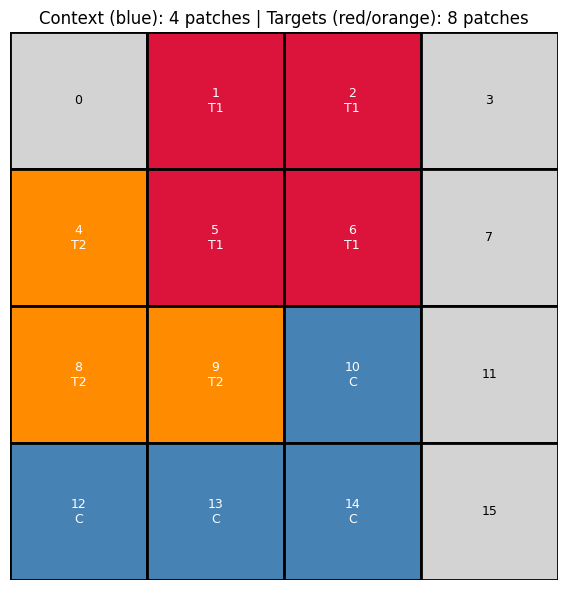

In [8]:
def visualize_context_and_targets(context_idx, target_indices_list, n_patches_per_dim):
    """Visualize context (blue) and targets (red/orange) on the grid"""
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    
    context_set = set(np.array(context_idx).tolist())
    target_sets = [set(np.array(t).tolist()) for t in target_indices_list]
    colors = ['crimson', 'darkorange', 'gold', 'coral']
    
    for i in range(n_patches_per_dim):
        for j in range(n_patches_per_dim):
            idx = i * n_patches_per_dim + j
            
            # Determine color
            facecolor = 'lightgray'
            label = ''
            
            if idx in context_set:
                facecolor = 'steelblue'
                label = 'C'
            
            for t_idx, target_set in enumerate(target_sets):
                if idx in target_set:
                    facecolor = colors[t_idx % len(colors)]
                    label = f'T{t_idx+1}'
                    break
            
            ax.add_patch(Rectangle((j, n_patches_per_dim-1-i), 1, 1, 
                                   facecolor=facecolor, edgecolor='black', linewidth=2))
            text = f'{idx}\n{label}' if label else f'{idx}'
            ax.text(j + 0.5, n_patches_per_dim - 0.5 - i, text, 
                   ha='center', va='center', fontsize=9,
                   color='white' if facecolor != 'lightgray' else 'black')
    
    ax.set_xlim(0, n_patches_per_dim)
    ax.set_ylim(0, n_patches_per_dim)
    ax.set_aspect('equal')
    ax.set_title(f'Context (blue): {len(context_set)} patches | Targets (red/orange): {sum(len(t) for t in target_sets)} patches')
    ax.axis('off')
    plt.tight_layout()
    return fig

visualize_context_and_targets(context_indices, [target1_indices, target2_indices], N_PATCHES_PER_DIM)
plt.show()

## 3. `apply_masks`: The Gather Operation

This is the **key function** that makes I-JEPA work. It selects tokens by index.

```
x: [N, D]        # All N patches, each D-dimensional
mask: [K]        # K indices to keep
output: [K, D]   # Only the K selected patches
```

No padding needed! The output length is just `len(mask)`.

In [9]:
def apply_masks(x, mask_indices):
    """Select patches by indices.
    
    Args:
        x: array of shape [N, D] - all patch embeddings
        mask_indices: array of shape [K] - indices of patches to keep
    
    Returns:
        selected: array of shape [K, D] - selected patch embeddings
    """
    return x[mask_indices]

# Batched version (what the real code uses)
def apply_masks_batched(x, mask_indices):
    """Batched version: select patches for each sample in batch.
    
    Args:
        x: [B, N, D] - batch of patch sequences
        mask_indices: [B, K] - indices per sample
    
    Returns:
        selected: [B, K, D]
    """
    # Use vmap over batch dimension
    return jax.vmap(lambda x_i, m_i: x_i[m_i])(x, mask_indices)

In [10]:
# Demo: create fake patch embeddings
D = 4  # embedding dimension (small for visualization)
key = jax.random.PRNGKey(0)

# Fake embeddings: each patch is [patch_idx, patch_idx, ...] so we can track them
x = jnp.stack([jnp.full(D, i) for i in range(N_PATCHES)], axis=0).astype(float)
print(f"All patches x: shape {x.shape}")
print(f"x[0] = {x[0]} (patch 0)")
print(f"x[5] = {x[5]} (patch 5)")

# Apply mask to select specific patches
mask = jnp.array([5, 6, 9, 10])  # A 2x2 block
selected = apply_masks(x, mask)

print(f"\nMask: {mask}")
print(f"Selected: shape {selected.shape}")
print(f"selected[0] = {selected[0]} (was patch 5)")
print(f"selected[1] = {selected[1]} (was patch 6)")

All patches x: shape (16, 4)
x[0] = [0. 0. 0. 0.] (patch 0)
x[5] = [5. 5. 5. 5.] (patch 5)

Mask: [ 5  6  9 10]
Selected: shape (4, 4)
selected[0] = [5. 5. 5. 5.] (was patch 5)
selected[1] = [6. 6. 6. 6.] (was patch 6)


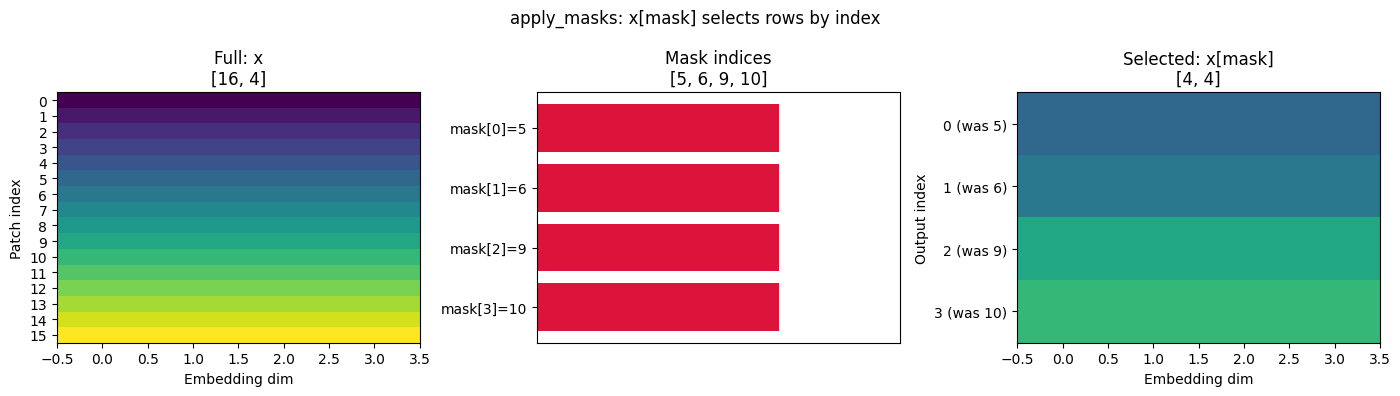

In [11]:
def visualize_apply_masks(n_patches, mask, embed_dim=4):
    """Visualize how apply_masks selects tokens"""
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    
    # Left: Full sequence
    ax = axes[0]
    ax.imshow(np.arange(n_patches).reshape(-1, 1) * np.ones((1, embed_dim)), 
              aspect='auto', cmap='viridis')
    ax.set_xlabel('Embedding dim')
    ax.set_ylabel('Patch index')
    ax.set_title(f'Full: x\n[{n_patches}, {embed_dim}]')
    ax.set_yticks(range(n_patches))
    
    # Middle: Mask indices
    ax = axes[1]
    ax.barh(range(len(mask)), [1]*len(mask), color='crimson')
    ax.set_yticks(range(len(mask)))
    ax.set_yticklabels([f'mask[{i}]={mask[i]}' for i in range(len(mask))])
    ax.set_title(f'Mask indices\n{list(mask)}')
    ax.invert_yaxis()
    ax.set_xlim(0, 1.5)
    ax.set_xticks([])
    
    # Right: Selected patches
    ax = axes[2]
    selected_values = np.array(mask).reshape(-1, 1) * np.ones((1, embed_dim))
    ax.imshow(selected_values, aspect='auto', cmap='viridis', 
              vmin=0, vmax=n_patches-1)
    ax.set_xlabel('Embedding dim')
    ax.set_ylabel('Output index')
    ax.set_title(f'Selected: x[mask]\n[{len(mask)}, {embed_dim}]')
    ax.set_yticks(range(len(mask)))
    ax.set_yticklabels([f'{i} (was {mask[i]})' for i in range(len(mask))])
    
    plt.suptitle('apply_masks: x[mask] selects rows by index', fontsize=12)
    plt.tight_layout()
    return fig

visualize_apply_masks(N_PATCHES, [5, 6, 9, 10])
plt.show()

## 4. 2D Positional Embeddings

Positional embeddings encode **where** each patch is in the 2D grid. Since we flatten to 1D, we need to preserve spatial information.

I-JEPA uses sinusoidal positional embeddings (not learned). The position is encoded separately for row and column.

In [12]:
def get_1d_sincos_pos_embed(embed_dim, grid_size):
    """1D sinusoidal positional embedding.
    
    Args:
        embed_dim: output dimension
        grid_size: number of positions
    
    Returns:
        pos_embed: [grid_size, embed_dim]
    """
    pos = jnp.arange(grid_size, dtype=jnp.float32)
    omega = jnp.arange(embed_dim // 2, dtype=jnp.float32)
    omega = 1.0 / (10000 ** (omega / (embed_dim // 2)))
    
    # Outer product: [grid_size, embed_dim//2]
    out = jnp.outer(pos, omega)
    
    emb_sin = jnp.sin(out)  # [grid_size, embed_dim//2]
    emb_cos = jnp.cos(out)  # [grid_size, embed_dim//2]
    
    return jnp.concatenate([emb_sin, emb_cos], axis=1)


def get_2d_sincos_pos_embed(embed_dim, grid_size):
    """2D sinusoidal positional embedding.
    
    Args:
        embed_dim: output dimension (must be divisible by 2)
        grid_size: height/width of the grid (assumes square)
    
    Returns:
        pos_embed: [grid_size*grid_size, embed_dim]
    """
    # Half the dimensions for row, half for column
    emb_h = get_1d_sincos_pos_embed(embed_dim // 2, grid_size)  # [grid_size, embed_dim//2]
    emb_w = get_1d_sincos_pos_embed(embed_dim // 2, grid_size)  # [grid_size, embed_dim//2]
    
    # Create 2D grid of positions
    # For each (row, col), concatenate [emb_h[row], emb_w[col]]
    pos_embed = jnp.concatenate([
        jnp.tile(emb_h[:, None, :], (1, grid_size, 1)),  # [H, W, D/2]
        jnp.tile(emb_w[None, :, :], (grid_size, 1, 1)),  # [H, W, D/2]
    ], axis=-1)
    
    return pos_embed.reshape(grid_size * grid_size, embed_dim)  # [H*W, D]

In [13]:
# Create positional embeddings for our 4x4 grid
EMBED_DIM = 32
pos_embed = get_2d_sincos_pos_embed(EMBED_DIM, N_PATCHES_PER_DIM)

print(f"Position embeddings shape: {pos_embed.shape}")
print(f"  -> {N_PATCHES} patches, each with {EMBED_DIM}-dim position encoding")

Position embeddings shape: (16, 32)
  -> 16 patches, each with 32-dim position encoding


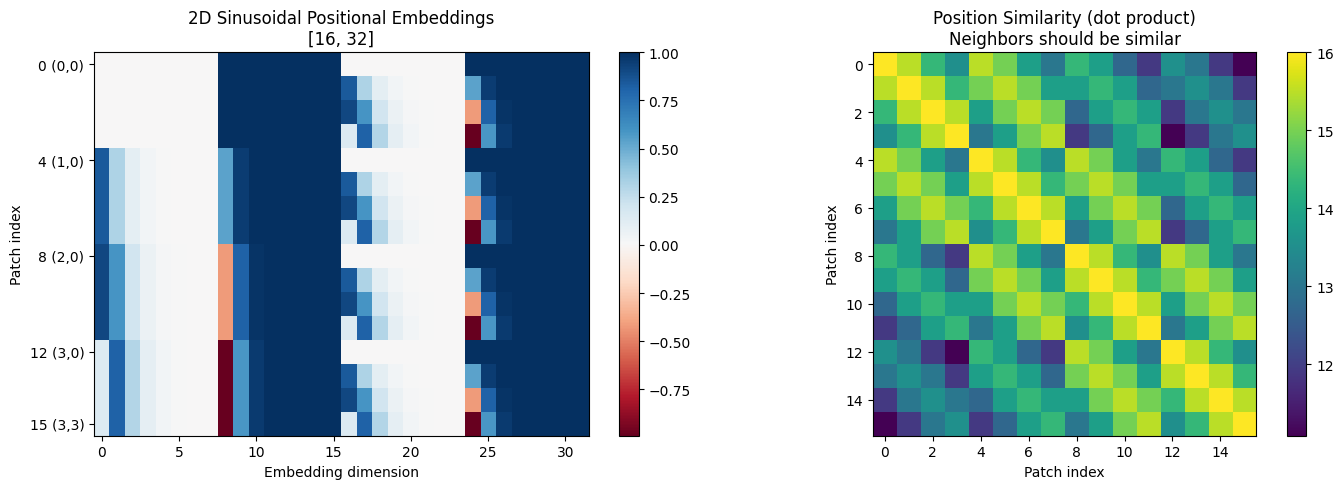

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Full positional embedding matrix
ax = axes[0]
im = ax.imshow(pos_embed, aspect='auto', cmap='RdBu')
ax.set_xlabel('Embedding dimension')
ax.set_ylabel('Patch index')
ax.set_title(f'2D Sinusoidal Positional Embeddings\n[{N_PATCHES}, {EMBED_DIM}]')
ax.set_yticks([0, 4, 8, 12, 15])
ax.set_yticklabels(['0 (0,0)', '4 (1,0)', '8 (2,0)', '12 (3,0)', '15 (3,3)'])
plt.colorbar(im, ax=ax)

# Right: Similarity matrix (how similar are positions?)
ax = axes[1]
similarity = pos_embed @ pos_embed.T
im = ax.imshow(similarity, cmap='viridis')
ax.set_xlabel('Patch index')
ax.set_ylabel('Patch index')
ax.set_title('Position Similarity (dot product)\nNeighbors should be similar')
plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

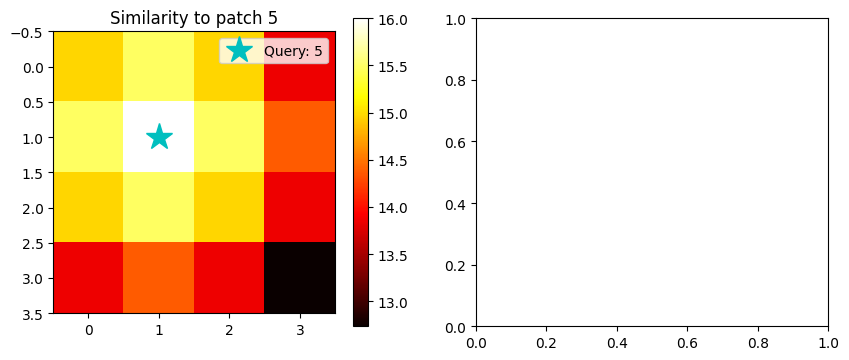

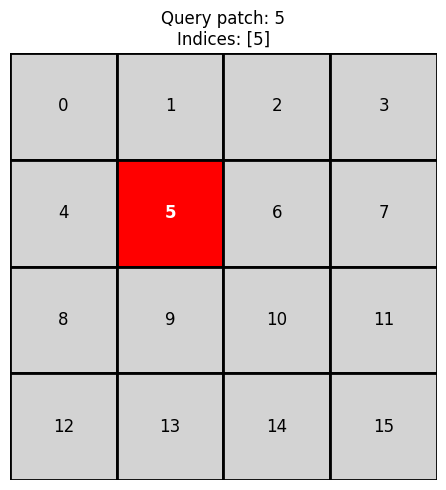

In [15]:
# Show that nearby patches have similar positional embeddings
def show_position_neighbors(pos_embed, query_idx, n_patches_per_dim):
    """Visualize which patches are 'close' to a query patch based on positional embeddings"""
    # Compute similarities
    query = pos_embed[query_idx]
    similarities = pos_embed @ query
    
    # Reshape to 2D for visualization
    sim_2d = similarities.reshape(n_patches_per_dim, n_patches_per_dim)
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    # Left: similarity heatmap
    ax = axes[0]
    im = ax.imshow(sim_2d, cmap='hot')
    qr, qc = idx_to_coords(query_idx, n_patches_per_dim)
    ax.plot(qc, qr, 'c*', markersize=20, label=f'Query: {query_idx}')
    ax.set_title(f'Similarity to patch {query_idx}')
    ax.legend()
    plt.colorbar(im, ax=ax)
    
    # Right: grid view with indices
    ax = axes[1]
    visualize_indices_on_grid([query_idx], n_patches_per_dim, f'Query patch: {query_idx}')
    
    plt.tight_layout()
    return fig

show_position_neighbors(pos_embed, 5, N_PATCHES_PER_DIM)
plt.show()

## 5. The Predictor Input: Context Tokens + Mask Tokens

This is **the core of I-JEPA**. The predictor receives:

1. **Context tokens**: Encoded patches from the context encoder, with their positional embeddings
2. **Mask tokens**: A single learned vector, repeated for each target position, with target positional embeddings added

```
predictor_input = concat([context_tokens, mask_tokens])
```

The mask tokens say: "Predict what should be **here** (at these positions)."

In [16]:
# Simulating predictor input construction

def create_predictor_input(
    context_embeddings,   # [N_ctx, D] - from context encoder
    context_indices,      # [N_ctx] - which patches are in context
    target_indices,       # [N_tgt] - which patches to predict
    pos_embed,            # [N_total, D] - positional embeddings
    mask_token,           # [D] - learned mask token
):
    """Construct the predictor's input sequence.
    
    Returns:
        pred_input: [N_ctx + N_tgt, D] - concatenated context + mask tokens
        n_context: int - number of context tokens (to slice output later)
    """
    # 1. Add positional embeddings to context tokens
    context_pos = pos_embed[context_indices]  # [N_ctx, D]
    context_with_pos = context_embeddings + context_pos
    
    # 2. Create mask tokens for target positions
    n_targets = len(target_indices)
    target_pos = pos_embed[target_indices]  # [N_tgt, D]
    # Repeat the single mask token and add target positions
    mask_tokens = jnp.tile(mask_token[None, :], (n_targets, 1)) + target_pos  # [N_tgt, D]
    
    # 3. Concatenate: [context_with_pos, mask_tokens]
    pred_input = jnp.concatenate([context_with_pos, mask_tokens], axis=0)
    
    return pred_input, len(context_indices)

In [17]:
# Demo: Create predictor input
key = jax.random.PRNGKey(42)

# Fake context embeddings (from context encoder)
ctx_indices = jnp.array([0, 1, 2, 4, 8, 12])  # 6 context patches
ctx_embeddings = jax.random.normal(key, (len(ctx_indices), EMBED_DIM))

# Target indices (what we want to predict)
tgt_indices = jnp.array([5, 6, 9, 10])  # 4 target patches

# Learned mask token (initialized randomly)
mask_token = jax.random.normal(jax.random.PRNGKey(1), (EMBED_DIM,)) * 0.02

# Create predictor input
pred_input, n_ctx = create_predictor_input(
    ctx_embeddings, ctx_indices, tgt_indices, pos_embed, mask_token
)

print(f"Context patches: {list(ctx_indices)} ({len(ctx_indices)} patches)")
print(f"Target patches: {list(tgt_indices)} ({len(tgt_indices)} patches)")
print(f"Predictor input shape: {pred_input.shape}")
print(f"  -> First {n_ctx} are context tokens")
print(f"  -> Last {len(tgt_indices)} are mask tokens (for target positions)")

Context patches: [Array(0, dtype=int32), Array(1, dtype=int32), Array(2, dtype=int32), Array(4, dtype=int32), Array(8, dtype=int32), Array(12, dtype=int32)] (6 patches)
Target patches: [Array(5, dtype=int32), Array(6, dtype=int32), Array(9, dtype=int32), Array(10, dtype=int32)] (4 patches)
Predictor input shape: (10, 32)
  -> First 6 are context tokens
  -> Last 4 are mask tokens (for target positions)


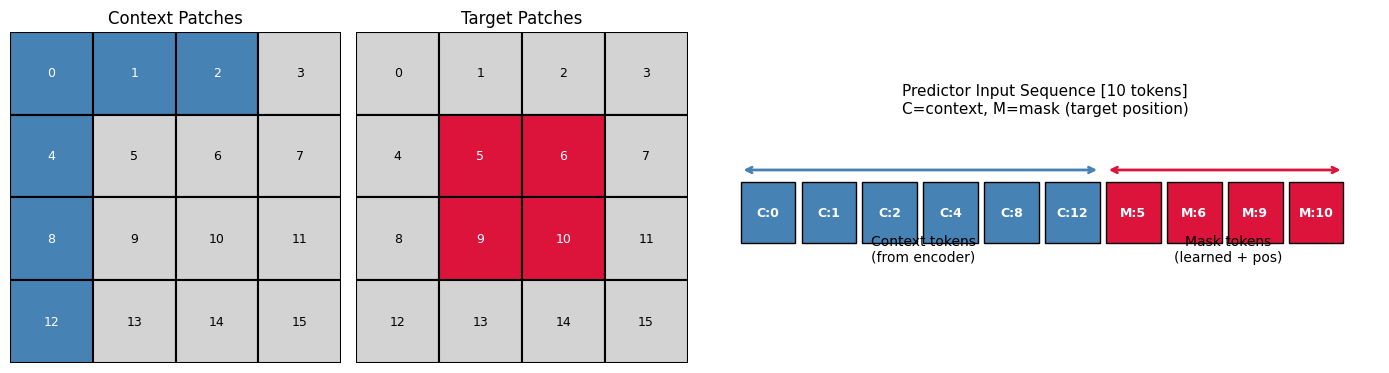

In [18]:
def visualize_predictor_input_construction(ctx_indices, tgt_indices, n_patches_per_dim):
    """Visualize how predictor input is constructed"""
    fig = plt.figure(figsize=(14, 5))
    
    # Grid 1: Context patches (blue)
    ax1 = fig.add_subplot(1, 4, 1)
    visualize_on_grid(ax1, ctx_indices, n_patches_per_dim, 'steelblue', 'Context Patches')
    
    # Grid 2: Target patches (red)  
    ax2 = fig.add_subplot(1, 4, 2)
    visualize_on_grid(ax2, tgt_indices, n_patches_per_dim, 'crimson', 'Target Patches')
    
    # Diagram: Predictor input sequence
    ax3 = fig.add_subplot(1, 2, 2)
    
    n_ctx = len(ctx_indices)
    n_tgt = len(tgt_indices)
    total = n_ctx + n_tgt
    
    # Draw sequence boxes
    for i in range(total):
        if i < n_ctx:
            color = 'steelblue'
            label = f'C:{ctx_indices[i]}'
        else:
            color = 'crimson'
            label = f'M:{tgt_indices[i-n_ctx]}'
        
        ax3.add_patch(Rectangle((i, 0), 0.9, 1, facecolor=color, edgecolor='black'))
        ax3.text(i + 0.45, 0.5, label, ha='center', va='center', 
                fontsize=9, color='white', fontweight='bold')
    
    ax3.set_xlim(-0.5, total + 0.5)
    ax3.set_ylim(-0.5, 2)
    ax3.set_aspect('equal')
    ax3.axis('off')
    
    # Add labels
    ax3.annotate('Context tokens\n(from encoder)', xy=(n_ctx/2, -0.3), fontsize=10, ha='center')
    ax3.annotate('Mask tokens\n(learned + pos)', xy=(n_ctx + n_tgt/2, -0.3), fontsize=10, ha='center')
    ax3.set_title(f'Predictor Input Sequence [{total} tokens]\nC=context, M=mask (target position)', fontsize=11)
    
    # Add bracket for context
    ax3.annotate('', xy=(0, 1.2), xytext=(n_ctx-0.1, 1.2),
                arrowprops=dict(arrowstyle='<->', color='steelblue', lw=2))
    # Add bracket for masks
    ax3.annotate('', xy=(n_ctx, 1.2), xytext=(total-0.1, 1.2),
                arrowprops=dict(arrowstyle='<->', color='crimson', lw=2))
    
    plt.tight_layout()
    return fig

def visualize_on_grid(ax, indices, n_patches_per_dim, color, title):
    indices_set = set(np.array(indices).tolist())
    for i in range(n_patches_per_dim):
        for j in range(n_patches_per_dim):
            idx = i * n_patches_per_dim + j
            is_selected = idx in indices_set
            facecolor = color if is_selected else 'lightgray'
            ax.add_patch(Rectangle((j, n_patches_per_dim-1-i), 1, 1, 
                                   facecolor=facecolor, edgecolor='black', linewidth=1.5))
            ax.text(j + 0.5, n_patches_per_dim - 0.5 - i, f'{idx}', 
                   ha='center', va='center', fontsize=9,
                   color='white' if is_selected else 'black')
    ax.set_xlim(0, n_patches_per_dim)
    ax.set_ylim(0, n_patches_per_dim)
    ax.set_aspect('equal')
    ax.set_title(title)
    ax.axis('off')

visualize_predictor_input_construction(ctx_indices, tgt_indices, N_PATCHES_PER_DIM)
plt.show()

## 6. Full I-JEPA Forward Pass (Simplified)

Now let's put it all together. This is a simplified version showing the data flow.

In [19]:
def ijepa_forward_simplified(
    image,              # [H, W, C] input image
    context_indices,    # [N_ctx] which patches form context
    target_indices,     # [N_tgt] which patches to predict
    # Model components (would be neural networks)
    patch_embed_fn,     # image -> [N, D] patch embeddings
    context_encoder_fn, # [N_ctx, D] -> [N_ctx, D] 
    target_encoder_fn,  # [N, D] -> [N, D]
    predictor_fn,       # [N_ctx + N_tgt, D] -> [N_ctx + N_tgt, D]
    pos_embed,          # [N, D] positional embeddings
    mask_token,         # [D] learned mask token
):
    """Simplified I-JEPA forward pass.
    
    Returns:
        predictions: [N_tgt, D] - predicted embeddings for target patches
        targets: [N_tgt, D] - actual embeddings from target encoder
    """
    # Step 1: Patchify image
    patches = patch_embed_fn(image)  # [N, D]
    N = patches.shape[0]
    
    # Step 2: Target encoder sees ALL patches (with pos embed)
    patches_with_pos = patches + pos_embed[:N]
    target_output = target_encoder_fn(patches_with_pos)  # [N, D]
    
    # Step 3: Extract targets at target positions
    targets = target_output[target_indices]  # [N_tgt, D]
    
    # Step 4: Context encoder sees ONLY context patches
    context_patches = patches[context_indices]  # [N_ctx, D]
    context_pos = pos_embed[context_indices]    # [N_ctx, D]
    context_output = context_encoder_fn(context_patches + context_pos)  # [N_ctx, D]
    
    # Step 5: Build predictor input (context + mask tokens)
    pred_input, n_ctx = create_predictor_input(
        context_output, context_indices, target_indices, pos_embed, mask_token
    )
    
    # Step 6: Predictor forward
    pred_output = predictor_fn(pred_input)  # [N_ctx + N_tgt, D]
    
    # Step 7: Extract predictions (last N_tgt positions)
    predictions = pred_output[n_ctx:]  # [N_tgt, D]
    
    return predictions, targets


def ijepa_loss(predictions, targets):
    """Smooth L1 loss between predictions and targets."""
    # In practice: F.smooth_l1_loss in PyTorch, or:
    diff = predictions - targets
    abs_diff = jnp.abs(diff)
    # Smooth L1: quadratic for small values, linear for large
    loss = jnp.where(abs_diff < 1.0, 0.5 * diff**2, abs_diff - 0.5)
    return loss.mean()

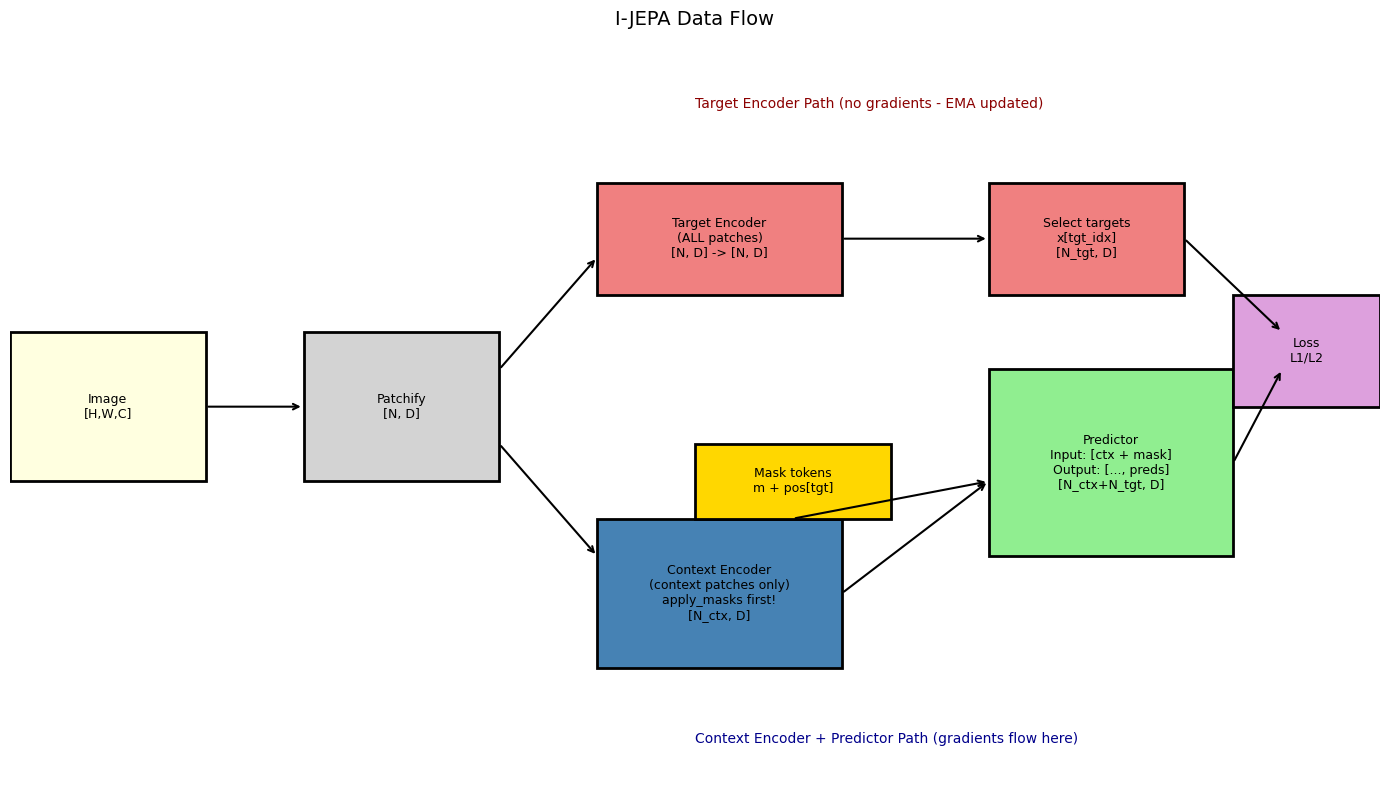

In [20]:
def visualize_ijepa_dataflow():
    """Create a diagram showing I-JEPA data flow"""
    fig, ax = plt.subplots(1, 1, figsize=(14, 8))
    ax.set_xlim(0, 14)
    ax.set_ylim(0, 10)
    ax.axis('off')
    
    # Helper to draw boxes
    def box(x, y, w, h, text, color='lightblue', fontsize=9):
        ax.add_patch(Rectangle((x, y), w, h, facecolor=color, edgecolor='black', linewidth=2))
        ax.text(x + w/2, y + h/2, text, ha='center', va='center', fontsize=fontsize, wrap=True)
    
    def arrow(x1, y1, x2, y2, text='', color='black'):
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                   arrowprops=dict(arrowstyle='->', color=color, lw=1.5))
        if text:
            ax.text((x1+x2)/2, (y1+y2)/2 + 0.2, text, fontsize=8, ha='center')
    
    # Image
    box(0, 4, 2, 2, 'Image\n[H,W,C]', 'lightyellow')
    
    # Patchify
    arrow(2, 5, 3, 5)
    box(3, 4, 2, 2, 'Patchify\n[N, D]', 'lightgray')
    
    # Split into two paths
    # Target path (top)
    arrow(5, 5.5, 6, 7)
    box(6, 6.5, 2.5, 1.5, 'Target Encoder\n(ALL patches)\n[N, D] -> [N, D]', 'lightcoral')
    arrow(8.5, 7.25, 10, 7.25)
    box(10, 6.5, 2, 1.5, 'Select targets\nx[tgt_idx]\n[N_tgt, D]', 'lightcoral')
    
    # Context path (bottom)
    arrow(5, 4.5, 6, 3)
    box(6, 1.5, 2.5, 2, 'Context Encoder\n(context patches only)\napply_masks first!\n[N_ctx, D]', 'steelblue')
    
    # Predictor
    arrow(8.5, 2.5, 10, 4)
    box(10, 3, 2.5, 2.5, 'Predictor\nInput: [ctx + mask]\nOutput: [..., preds]\n[N_ctx+N_tgt, D]', 'lightgreen')
    
    # Mask tokens
    box(7, 3.5, 2, 1, 'Mask tokens\nm + pos[tgt]', 'gold')
    arrow(8, 3.5, 10, 4)
    
    # Loss
    arrow(12, 7.25, 13, 6)
    arrow(12.5, 4.25, 13, 5.5)
    box(12.5, 5, 1.5, 1.5, 'Loss\nL1/L2', 'plum')
    
    # Labels
    ax.text(7, 9, 'Target Encoder Path (no gradients - EMA updated)', fontsize=10, color='darkred')
    ax.text(7, 0.5, 'Context Encoder + Predictor Path (gradients flow here)', fontsize=10, color='darkblue')
    
    ax.set_title('I-JEPA Data Flow', fontsize=14)
    plt.tight_layout()
    return fig

visualize_ijepa_dataflow()
plt.show()

## 7. Key Takeaways

1. **No padding tokens**: Images are resized to exact multiples of patch size. Variable-length context/target is handled by `apply_masks` selecting different indices.

2. **Masks are index lists**: A block is just `[5, 6, 9, 10]` - the 2D shape doesn't matter to the model.

3. **`apply_masks(x, indices)`**: The key operation - just `x[indices]`. No padding, no attention masks.

4. **Positional embeddings carry geometry**: 2D sinusoidal embeddings encode (row, col) position. This is how the predictor knows *where* to predict.

5. **Mask tokens**: One learned vector repeated per target position, with target positional embeddings added.

6. **Predictor input**: `concat([context_tokens, mask_tokens])` - context says "what we see", masks say "where to predict".

7. **Target encoder**: Sees ALL patches, but only the target indices are used for the loss.

In [21]:
# Summary: The core operations in ~20 lines

def apply_masks(x, indices):
    """Select tokens by index: x[N, D], indices[K] -> [K, D]"""
    return x[indices]

def create_mask_tokens(mask_token, target_indices, pos_embed):
    """Create mask tokens for target positions."""
    n_targets = len(target_indices)
    target_pos = pos_embed[target_indices]
    return jnp.tile(mask_token[None, :], (n_targets, 1)) + target_pos

def predictor_input(context_emb, context_idx, target_idx, pos_embed, mask_token):
    """Build predictor input: context + mask tokens."""
    ctx_with_pos = context_emb + pos_embed[context_idx]
    mask_tokens = create_mask_tokens(mask_token, target_idx, pos_embed)
    return jnp.concatenate([ctx_with_pos, mask_tokens], axis=0)

print("Core I-JEPA operations:")
print("1. apply_masks: x[indices] - select patches")
print("2. create_mask_tokens: tile(mask_token) + pos[targets]")
print("3. predictor_input: concat([context + pos, mask_tokens])")

Core I-JEPA operations:
1. apply_masks: x[indices] - select patches
2. create_mask_tokens: tile(mask_token) + pos[targets]
3. predictor_input: concat([context + pos, mask_tokens])
